In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamprateek/wallmart-sales-forecast-datasets")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 3.36M/3.36M [00:05<00:00, 594kB/s]

Extracting files...


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\iamprateek\wallmart-sales-forecast-datasets\versions\1


In [2]:
import pandas as pd
import numpy as np
import os # Import the os module to join paths

# 'path' is the variable from your previous cell
# It points to the 'versions/1' folder
data_path = path 

# Define the full paths to your files
train_file = os.path.join(data_path, 'train.csv')
features_file = os.path.join(data_path, 'features.csv')
stores_file = os.path.join(data_path, 'stores.csv')

# Load the datasets
train_df = pd.read_csv(train_file)
features_df = pd.read_csv(features_file)
stores_df = pd.read_csv(stores_file)

print("--- Data Loaded Successfully ---")
print("Train Shape:", train_df.shape)
print("Features Shape:", features_df.shape)
print("Stores Shape:", stores_df.shape)

--- Data Loaded Successfully ---
Train Shape: (421570, 5)
Features Shape: (8190, 12)
Stores Shape: (45, 3)


In [3]:
# --- 1. Merge DataFrames ---
# Merge stores info into features
features_stores_df = features_df.merge(stores_df, on='Store', how='left')

# Merge all features into the training data
# This creates your master dataset
df = train_df.merge(features_stores_df, on=['Store', 'Date', 'IsHoliday'], how='left')

print("\n--- Data Merged ---")
print("Master DataFrame shape:", df.shape)
print(df.head())

# --- 2. Handle Missing Values ---
print("\n--- Cleaning Data ---")
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Simple strategy: Fill NaNs for numerical data. 
# CPI & Unemployment are geographic, so forward-fill is a good strategy.
# We sort by Store/Date first to make ffill logical
df = df.sort_values(by=['Store', 'Date'])
df['CPI'] = df['CPI'].fillna(method='ffill')
df['Unemployment'] = df['Unemployment'].fillna(method='ffill')

# For markdown, NaN means "no markdown," so fill with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# Drop any other rows that might have NaNs (e.g., from the merge)
df = df.dropna()

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())
print("\n--- Merging & Cleaning Complete ---")


--- Data Merged ---
Master DataFrame shape: (421570, 16)
   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size

C:\Users\USER\AppData\Local\Temp\ipykernel_20700\374320647.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CPI'] = df['CPI'].fillna(method='ffill')
C:\Users\USER\AppData\Local\Temp\ipykernel_20700\374320647.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Unemployment'] = df['Unemployment'].fillna(method='ffill')



Missing values AFTER cleaning:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

--- Merging & Cleaning Complete ---


## Convert Date:

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set_style("whitegrid")

# 1. Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
print("Converted 'Date' column to datetime.")

Converted 'Date' column to datetime.


## Analyze the Core Relationship (Temperature):

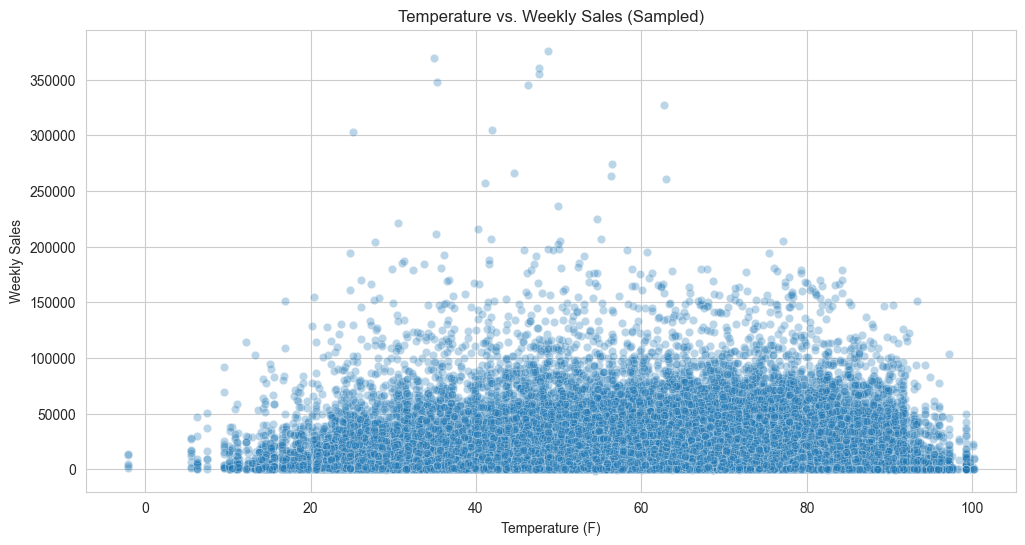

In [5]:
# 2. Plot Temperature vs. Weekly_Sales
# Use sample() to avoid overplotting and make it run faster
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df.sample(50000), x='Temperature', y='Weekly_Sales', alpha=0.3)
plt.title('Temperature vs. Weekly Sales (Sampled)')
plt.xlabel('Temperature (F)')
plt.ylabel('Weekly Sales')
plt.show()

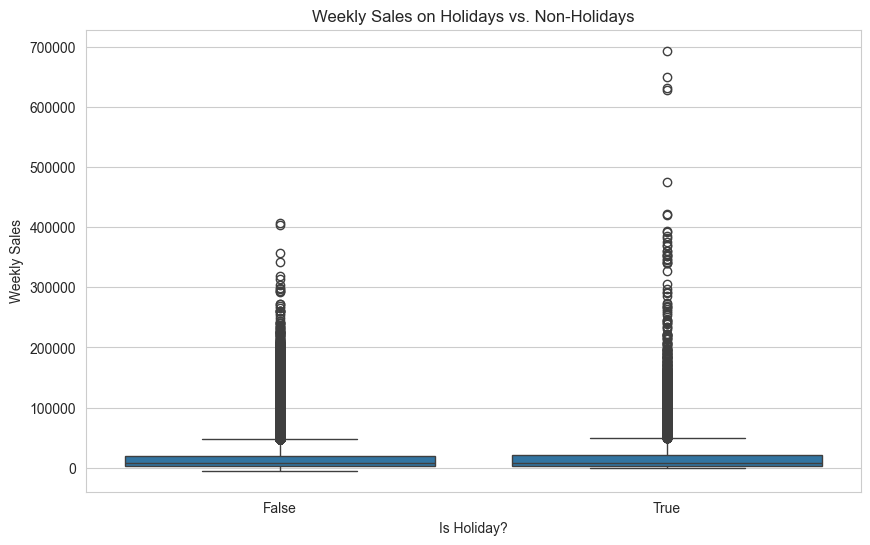

In [6]:
# 3. Analyze Holidays
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales')
plt.title('Weekly Sales on Holidays vs. Non-Holidays')
plt.ylabel('Weekly Sales')
plt.xlabel('Is Holiday?')
# This often shows surprising results (e.g., lower sales on holiday weeks)
plt.show()

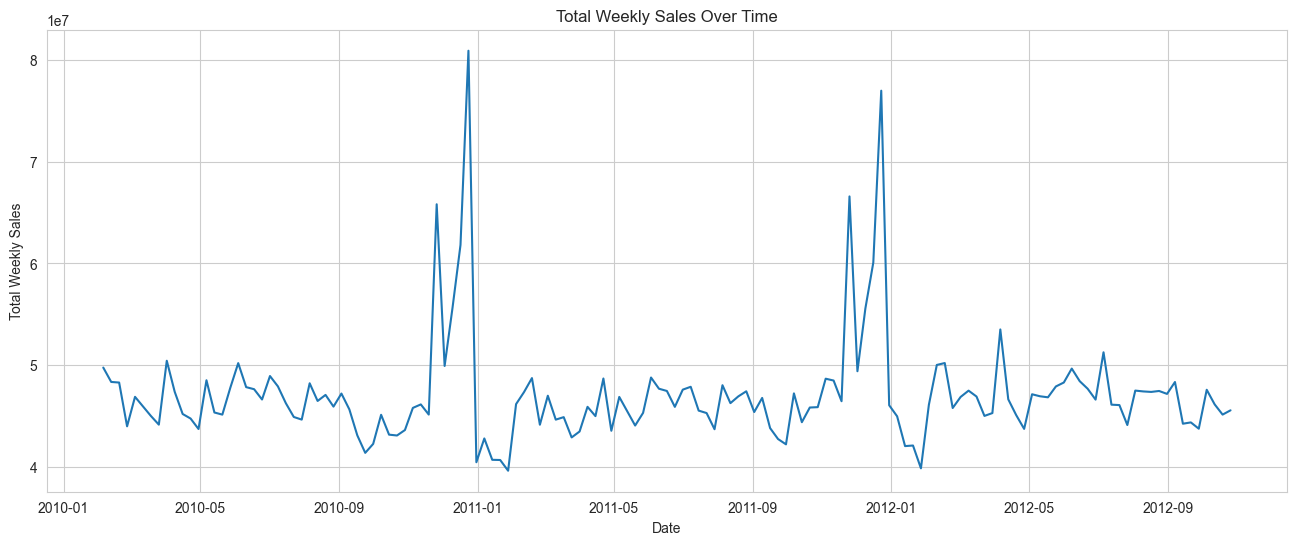

In [7]:
# 4. Sales Over Time (Aggregated)
# Group by date to get total sales across all stores
df_time = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_time, x='Date', y='Weekly_Sales')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

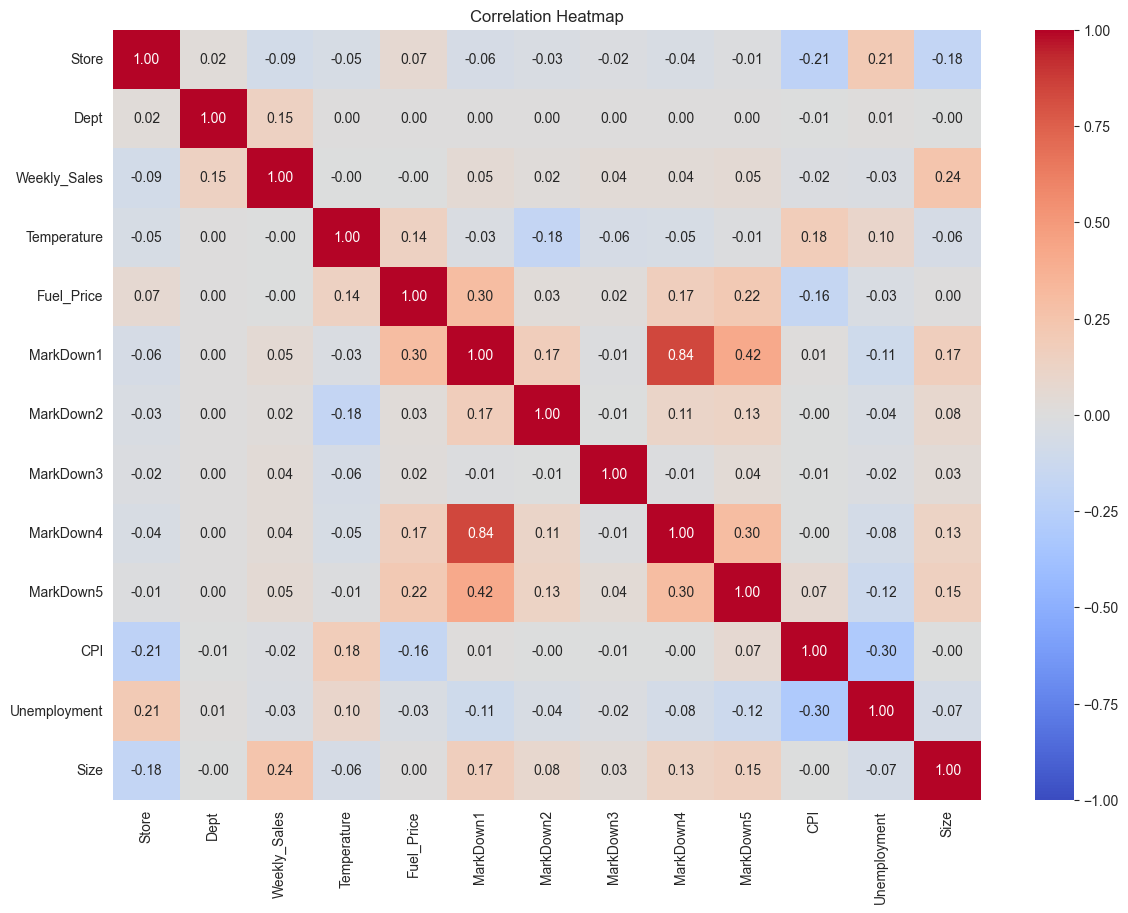

In [8]:
# 5. Correlation Heatmap
plt.figure(figsize=(14, 10))
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [9]:
print("--- Starting Feature Engineering ---")

# --- 1. Time-Based Features ---
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
print("Created Time-Based Features: Month, Year, WeekOfYear")

--- Starting Feature Engineering ---
Created Time-Based Features: Month, Year, WeekOfYear


In [10]:
# --- 2. Lag Features ---
# We MUST sort by Date, and group by Store/Dept to lag sales correctly
df = df.sort_values(by=['Store', 'Dept', 'Date'])
df['Sales_Lag_1_Week'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
print("Created Lag Feature: Sales_Lag_1_Week")

Created Lag Feature: Sales_Lag_1_Week


In [11]:
# --- 3. Rolling Average Features ---
df['Sales_Avg_4_Weeks'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(4).mean()
print("Created Rolling Average Feature: Sales_Avg_4_Weeks")

Created Rolling Average Feature: Sales_Avg_4_Weeks


In [12]:
# --- 4. Categorical Features ---
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
print("Converted 'Type' column to dummy variables")

Converted 'Type' column to dummy variables


In [13]:
# --- 5. Clean Up NaNs ---
# The lag/rolling features created NaNs for the first few rows of each group.
# We must drop these rows as we cannot train on them.
initial_rows = df.shape[0]
df = df.dropna(subset=['Sales_Lag_1_Week', 'Sales_Avg_4_Weeks'])
final_rows = df.shape[0]

In [14]:
print(f"\nDropped {initial_rows - final_rows} rows containing NaNs from lagging/rolling.")
print("--- Feature Engineering Complete ---")
print("\nFinal DataFrame head:")
print(df.head())


Dropped 13134 rows containing NaNs from lagging/rolling.
--- Feature Engineering Complete ---

Final DataFrame head:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
4      1     1 2010-03-05      21827.90      False        46.50       2.625   
5      1     1 2010-03-12      21043.39      False        57.79       2.667   
6      1     1 2010-03-19      22136.64      False        54.58       2.720   
7      1     1 2010-03-26      26229.21      False        51.45       2.732   
8      1     1 2010-04-02      57258.43      False        62.27       2.719   

   MarkDown1  MarkDown2  MarkDown3  ...         CPI  Unemployment    Size  \
4        0.0        0.0        0.0  ...  211.350143         8.106  151315   
5        0.0        0.0        0.0  ...  211.380643         8.106  151315   
6        0.0        0.0        0.0  ...  211.215635         8.106  151315   
7        0.0        0.0        0.0  ...  211.018042         8.106  151315   
8        0.0        0.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# --- 1. Define Features (X) and Target (y) ---
# We include all our new features and exclude the original Date/Sales
features = [
    'Store', 'Dept', 'Temperature', 'Fuel_Price', 'IsHoliday', 'CPI', 
    'Unemployment', 'Size', 'Month', 'Year', 'WeekOfYear', 
    'Sales_Lag_1_Week', 'Sales_Avg_4_Weeks', 'Type_B', 'Type_C'
]

target = 'Weekly_Sales'

X = df[features]
y = df[target]

In [19]:
# --- 2. Create Time-Series Split (CRITICAL) ---
# We will use the last 6 months of data as our test set
split_date = df['Date'].max() - pd.DateOffset(months=6)

# Create boolean masks for splitting
train_mask = (df['Date'] < split_date)
test_mask = (df['Date'] >= split_date)

# Apply masks to X and y
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"--- Data Split ---")
print(f"Training on {len(X_train)} samples (before {split_date})")
print(f"Testing on {len(X_test)} samples (after {split_date})")
print(f"Total features: {len(features)}")

--- Data Split ---
Training on 328635 samples (before 2012-04-26 00:00:00)
Testing on 79801 samples (after 2012-04-26 00:00:00)
Total features: 15


In [20]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 3. Helper Function for Business-Focused Metrics (Improved) ---
def calculate_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-6 
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    
    print(f"\n--- Metrics for {model_name} ---")
    print(f"  RMSE: ${rmse:,.2f}  (Average prediction error in dollars)")
    print(f"  MAE:  ${mae:,.2f}  (Average absolute error in dollars)")
    print(f"  MAPE: {mape:.2f}%     (Average prediction error in percentage)")
    return rmse, mae, mape
    
# --- Model 1: Baseline (Linear Regression) ---
print("\nTraining Linear Regression (Baseline)...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
calculate_metrics(y_test, lr_preds, "Linear Regression")


Training Linear Regression (Baseline)...

--- Metrics for Linear Regression ---
  RMSE: $3,249.40  (Average prediction error in dollars)
  MAE:  $1,556.91  (Average absolute error in dollars)
  MAPE: 5104589.60%     (Average prediction error in percentage)


(3249.4048103937175, 1556.9083011945304, 5104589.598546788)

In [21]:
# --- Model 2: Workhorse (Random Forest) ---
# We use max_depth=15 and n_estimators=100 for a good balance of speed/accuracy
print("\nTraining Random Forest (This may take a moment)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, 
                                 n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
calculate_metrics(y_test, rf_preds, "Random Forest")


Training Random Forest (This may take a moment)...

--- Metrics for Random Forest ---
  RMSE: $3,090.12  (Average prediction error in dollars)
  MAE:  $1,418.71  (Average absolute error in dollars)
  MAPE: 1099155.37%     (Average prediction error in percentage)


(3090.119129831539, 1418.7124301747456, 1099155.3735591946)

In [22]:
# --- Model 3: The "Stunning" Model (XGBoost) - CORRECTED ---
print("\nTraining XGBoost (Corrected)...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05,
    n_jobs=-1, 
    random_state=42,
    early_stopping_rounds=10,  # Set early stopping in the constructor
    eval_metric='rmse'         # Set eval_metric in the constructor
)

# Now, the .fit() method only needs the validation data
xgb_model.fit(X_train, y_train, 
              eval_set=[(X_test, y_test)], 
              verbose=False) # Set to True if you want to see training progress

xgb_preds = xgb_model.predict(X_test)
calculate_metrics(y_test, xgb_preds, "XGBoost")

print("\n--- Model Training Complete ---")


Training XGBoost (Corrected)...

--- Metrics for XGBoost ---
  RMSE: $3,038.51  (Average prediction error in dollars)
  MAE:  $1,410.71  (Average absolute error in dollars)
  MAPE: 1883548.93%     (Average prediction error in percentage)

--- Model Training Complete ---


In [23]:
import joblib
import pandas as pd

# --- 1. Save the Best Model (XGBoost) ---
# We use joblib for efficient model saving
joblib.dump(xgb_model, 'xgb_sales_model.pkl')
print("Saved XGBoost model to 'xgb_sales_model.pkl'")

# --- 2. Save Test Results for the Dashboard ---
# Create a new DataFrame with the test data, actuals, and predictions
test_results = X_test.copy()

# We need the 'Date' column from the original df for plotting
test_results['Date'] = df.loc[test_mask, 'Date']
test_results['Actual_Sales'] = y_test
test_results['Predicted_Sales'] = xgb_preds # The predictions you just made

# Save to a CSV file
test_results.to_csv('test_results_for_dashboard.csv', index=False)
print("Saved test results to 'test_results_for_dashboard.csv'")

Saved XGBoost model to 'xgb_sales_model.pkl'
Saved test results to 'test_results_for_dashboard.csv'


In [24]:
!pip install streamlit